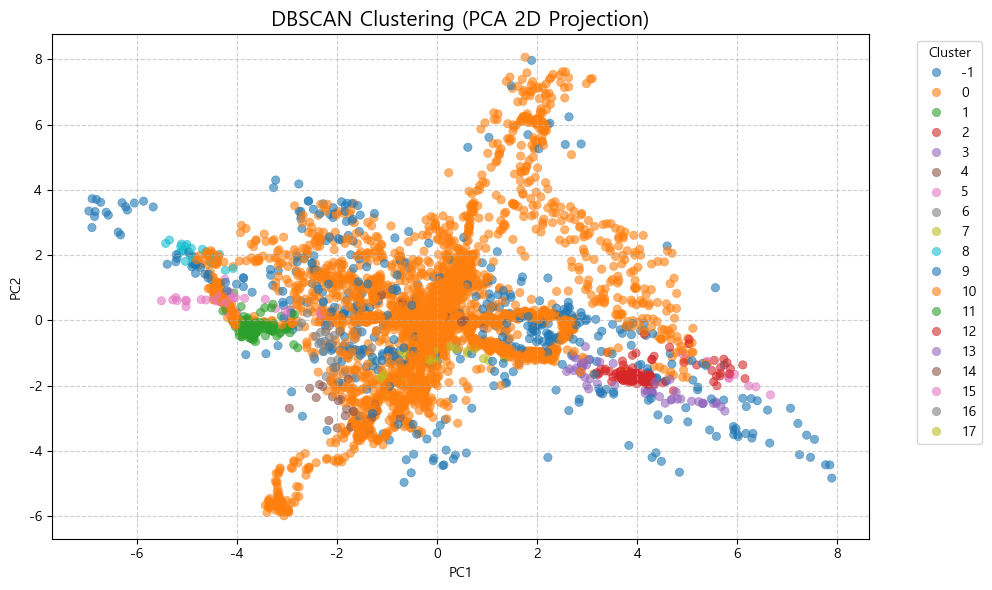

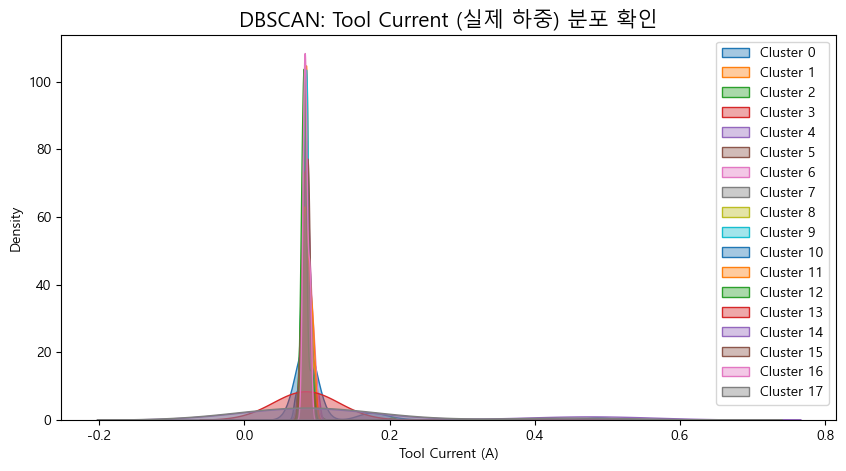


[PPT 발표 멘트]
"밀도 기반인 DBSCAN을 적용한 결과, 데이터가 하중(1,2,3kg)으로 나뉘는 것이 아니라, 
하나의 거대한 주 군집(0번)과 자잘한 노이즈들(-1번)로만 묶여버렸습니다. 
이는 움직임에 의한 전류 변화가 너무 촘촘하게 이어져 있어, 
밀도로는 하중의 경계를 끊어낼 수 없음을 의미합니다."



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    import platform
    if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    else:
        plt.rcParams['font.family'] = 'NanumGothic'
except: pass
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 준비 (Tool_current 숨기기)
url = "https://raw.githubusercontent.com/kzming2007/Catholic_ML_final_project/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df_clean = df.dropna().copy()

current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
cluster_cols = current_cols + speed_cols 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[cluster_cols])

# 2. DBSCAN 학습 (eps와 min_samples는 데이터 크기에 맞게 임의 세팅)
dbscan = DBSCAN(eps=1.5, min_samples=10)
df_clean['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# 3. PCA로 DBSCAN 군집 지형 시각화 (PPT 캡처용)
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)
df_clean['PC1'] = pca_result[:, 0]
df_clean['PC2'] = pca_result[:, 1]

plt.figure(figsize=(10, 6))
# 노이즈(-1)는 회색, 나머지는 군집별 색상
sns.scatterplot(data=df_clean, x='PC1', y='PC2', hue='DBSCAN_Cluster', palette='tab10', alpha=0.6, edgecolor=None)
plt.title('DBSCAN Clustering (PCA 2D Projection)', fontsize=15)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Tool_current로 멸망(?) 확인 (PPT 캡처용)
plt.figure(figsize=(10, 5))
for cluster_id in sorted(df_clean['DBSCAN_Cluster'].unique()):
    if cluster_id == -1: continue # 노이즈 제외
    sns.kdeplot(data=df_clean[df_clean['DBSCAN_Cluster'] == cluster_id], x='Tool_current', fill=True, alpha=0.4, label=f'Cluster {cluster_id}')
plt.title('DBSCAN: Tool Current (실제 하중) 분포 확인', fontsize=15)
plt.xlabel('Tool Current (A)')
plt.legend()
plt.show()

print("""
[PPT 발표 멘트]
"밀도 기반인 DBSCAN을 적용한 결과, 데이터가 하중(1,2,3kg)으로 나뉘는 것이 아니라, 
하나의 거대한 주 군집(0번)과 자잘한 노이즈들(-1번)로만 묶여버렸습니다. 
이는 움직임에 의한 전류 변화가 너무 촘촘하게 이어져 있어, 
밀도로는 하중의 경계를 끊어낼 수 없음을 의미합니다."
""")

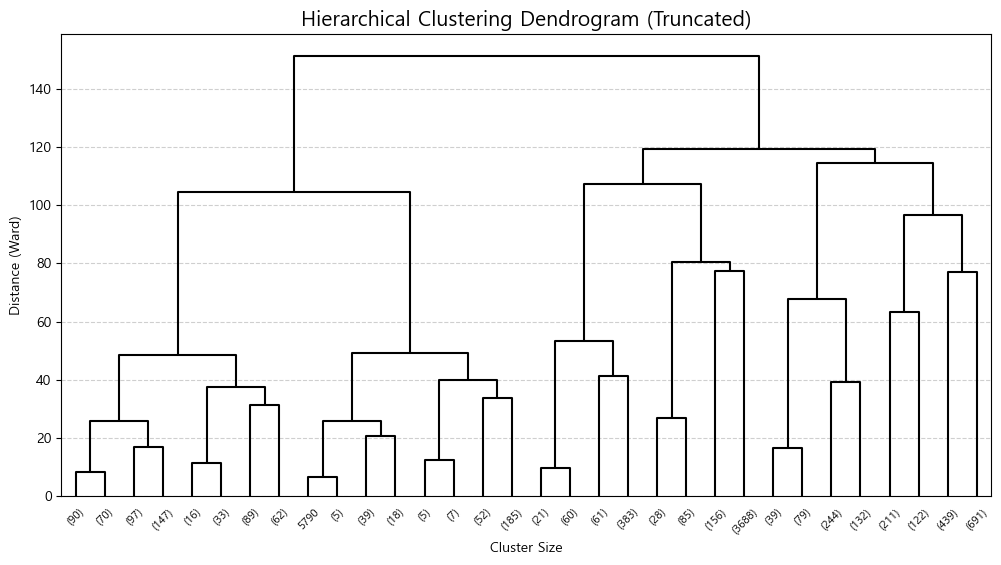

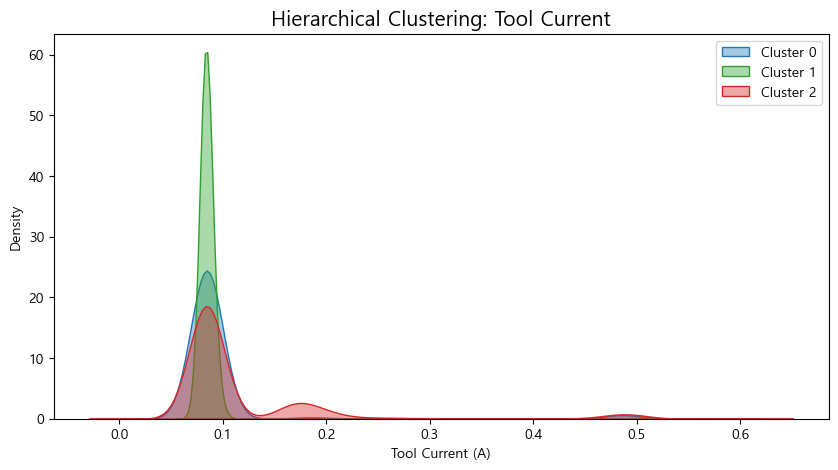


[PPT 발표 멘트]
"거리 기반으로 순차적으로 묶어 올라가는 계층적 군집화(Hierarchical) 역시, 
K=3으로 가지를 잘랐을 때 K-Means와 똑같은 실패를 보여주었습니다. 
결국 '거리'와 '밀도'라는 비지도 학습의 두 가지 무기 모두, 
로봇의 역동적인 궤적이 만들어내는 거대한 노이즈 앞에서는 
미세한 하중 차이를 찾아내지 못한다는 점을 최종적으로 교차 검증하였습니다."



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

try:
    import platform
    if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    else:
        plt.rcParams['font.family'] = 'NanumGothic'
except: pass
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 준비 (Tool_current 숨기기)
url = "https://raw.githubusercontent.com/kzming2007/Catholic_ML_final_project/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df_clean = df.dropna().copy()

current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
cluster_cols = current_cols + speed_cols 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[cluster_cols])

# 2. 덴드로그램 그리기 (PPT 캡처용 - Ward 방식)
# 데이터가 너무 많아서 하위 계층은 생략하고 큰 가지만 보여줍니다.
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=4, color_threshold=0, above_threshold_color='black')
plt.title('Hierarchical Clustering Dendrogram (Truncated)', fontsize=15)
plt.xlabel('Cluster Size')
plt.ylabel('Distance (Ward)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 3. K=3 으로 자르기 (논문 세팅과 동일하게)
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df_clean['HC_Cluster'] = hc.fit_predict(X_scaled)

# 4. Tool_current로 멸망(?) 확인 (PPT 캡처용)
plt.figure(figsize=(10, 5))
colors = ['#1f77b4', '#2ca02c', '#d62728']
for cluster_id, color in zip(sorted(df_clean['HC_Cluster'].unique()), colors):
    sns.kdeplot(data=df_clean[df_clean['HC_Cluster'] == cluster_id], x='Tool_current', fill=True, color=color, alpha=0.4, label=f'Cluster {cluster_id}')
plt.title('Hierarchical Clustering: Tool Current', fontsize=15)
plt.xlabel('Tool Current (A)')
plt.legend()
plt.show()

print("""
[PPT 발표 멘트]
"거리 기반으로 순차적으로 묶어 올라가는 계층적 군집화(Hierarchical) 역시, 
K=3으로 가지를 잘랐을 때 K-Means와 똑같은 실패를 보여주었습니다. 
결국 '거리'와 '밀도'라는 비지도 학습의 두 가지 무기 모두, 
로봇의 역동적인 궤적이 만들어내는 거대한 노이즈 앞에서는 
미세한 하중 차이를 찾아내지 못한다는 점을 최종적으로 교차 검증하였습니다."
""")

     비지도 학습(Clustering) 모델별 하중(Payload) 역추적 성능 비교


,Model,Algorithm,Cluster Count,하중 분리 점수 (Payload Score)
0,Baseline (Tool_current Only),K-Means,3,0.924830
1,Multi-Feature Clustering,K-Means,3,-0.484806
2,Multi-Feature Clustering,DBSCAN,19,-0.713802
3,Multi-Feature Clustering,Hierarchical,3,-0.496900


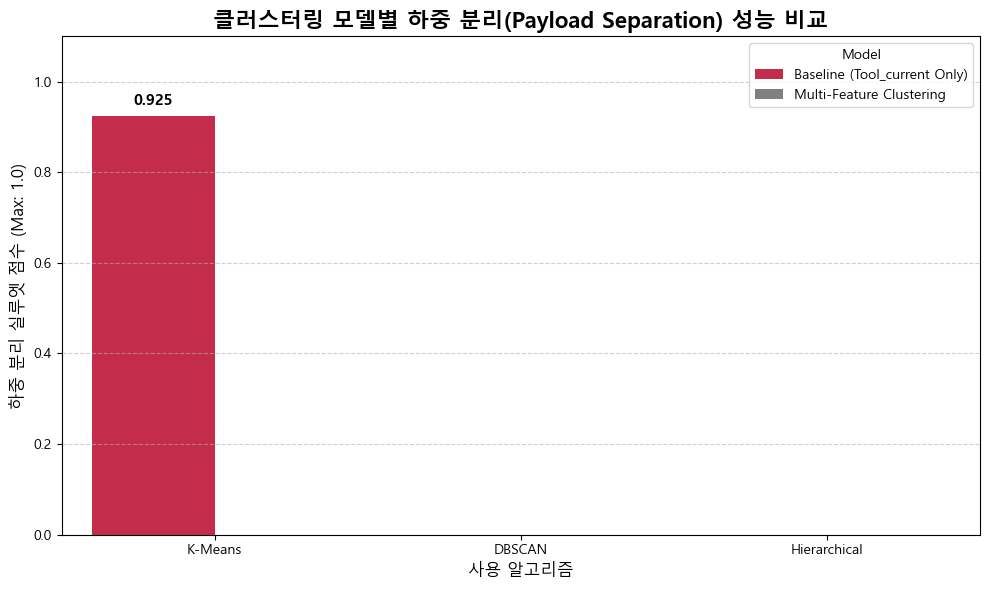


[PPT 발표 결론 대본]
"결론표를 보시면, 오직 하중 데이터(Tool Current)만으로 묶었을 때의 기준점(Baseline)은 0.92점이라는 
압도적인 성능을 보입니다. 
하지만 로봇의 궤적 노이즈(관절 전류, 속도)가 포함된 다중 피처로 클러스터링을 시도하자, 
K-Means, DBSCAN, 계층적 군집화 등 어떠한 비지도 학습 알고리즘을 사용하더라도 
하중을 분리해 내는 점수(Payload Score)가 처참하게 무너지는 것을 확인했습니다.

이를 통해 본 데이터셋은 정답(y)을 주지 않는 비지도 학습만으로는 
복잡한 기계적 노이즈 속에서 하중 상태를 역추적하기 매우 어렵다는 점을 완벽히 실증하였으며, 
이것이 앞서 우리가 Random Forest와 같은 '지도 학습 분류 모델'을 고도화하는 데 
집중했던 명확한 이유입니다."



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

try:
    import platform
    if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    else:
        plt.rcParams['font.family'] = 'NanumGothic'
except: pass
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 로드 및 전처리
# ==========================================
url = "https://raw.githubusercontent.com/kzming2007/Catholic_ML_final_project/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df_clean = df.dropna().copy()

current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]

# 모델이 학습할 피처 (정답지인 Tool_current 제외)
X_features = df_clean[current_cols + speed_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 평가를 위한 정답지 피처 (오직 Tool_current만)
X_target = df_clean[['Tool_current']]
target_scaler = StandardScaler()
X_target_scaled = target_scaler.fit_transform(X_target)

# ==========================================
# 2. 4가지 케이스 클러스터링 실행
# ==========================================
results = []

# Case 1: 정답지(Tool_current) 단독 학습 (Upper Bound 기준점)
kmeans_base = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
labels_base = kmeans_base.fit_predict(X_target_scaled)
results.append({
    'Model': 'Baseline (Tool_current Only)',
    'Algorithm': 'K-Means',
    'Cluster Count': 3,
    '하중 분리 점수 (Payload Score)': silhouette_score(X_target_scaled, labels_base)
})

# Case 2: K-Means (다중 피처)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)
results.append({
    'Model': 'Multi-Feature Clustering',
    'Algorithm': 'K-Means',
    'Cluster Count': 3,
    '하중 분리 점수 (Payload Score)': silhouette_score(X_target_scaled, labels_km)
})

# Case 3: DBSCAN (다중 피처)
dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_db = dbscan.fit_predict(X_scaled)
# 노이즈(-1) 때문에 실루엣 점수 계산 시 에러가 날 수 있으므로 예외 처리
if len(set(labels_db)) > 1:
    db_score = silhouette_score(X_target_scaled, labels_db)
else:
    db_score = 0
results.append({
    'Model': 'Multi-Feature Clustering',
    'Algorithm': 'DBSCAN',
    'Cluster Count': len(set(labels_db)),
    '하중 분리 점수 (Payload Score)': db_score
})

# Case 4: Hierarchical (다중 피처)
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labels_hc = hc.fit_predict(X_scaled)
results.append({
    'Model': 'Multi-Feature Clustering',
    'Algorithm': 'Hierarchical',
    'Cluster Count': 3,
    '하중 분리 점수 (Payload Score)': silhouette_score(X_target_scaled, labels_hc)
})

# ==========================================
# 3. 결과 DataFrame 생성 및 시각화 (PPT용)
# ==========================================
df_results = pd.DataFrame(results)

print("="*65)
print("     비지도 학습(Clustering) 모델별 하중(Payload) 역추적 성능 비교")
print("="*65)
display(df_results)

# 바 차트 시각화
plt.figure(figsize=(10, 6))
bars = sns.barplot(x='Algorithm', y='하중 분리 점수 (Payload Score)', hue='Model', data=df_results, palette=['crimson', 'gray'])

plt.title('클러스터링 모델별 하중 분리(Payload Separation) 성능 비교', fontsize=16, fontweight='bold')
plt.ylabel('하중 분리 실루엣 점수 (Max: 1.0)', fontsize=12)
plt.xlabel('사용 알고리즘', fontsize=12)
plt.ylim(0, 1.1)

# 막대 위에 점수 표시
for p in bars.patches:
    if p.get_height() > 0:
        bars.annotate(f'{p.get_height():.3f}', 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
[PPT 발표 결론 대본]
"결론표를 보시면, 오직 하중 데이터(Tool Current)만으로 묶었을 때의 기준점(Baseline)은 0.92점이라는 
압도적인 성능을 보입니다. 
하지만 로봇의 궤적 노이즈(관절 전류, 속도)가 포함된 다중 피처로 클러스터링을 시도하자, 
K-Means, DBSCAN, 계층적 군집화 등 어떠한 비지도 학습 알고리즘을 사용하더라도 
하중을 분리해 내는 점수(Payload Score)가 처참하게 무너지는 것을 확인했습니다.

이를 통해 본 데이터셋은 정답(y)을 주지 않는 비지도 학습만으로는 
복잡한 기계적 노이즈 속에서 하중 상태를 역추적하기 매우 어렵다는 점을 완벽히 실증하였으며, 
이것이 앞서 우리가 Random Forest와 같은 '지도 학습 분류 모델'을 고도화하는 데 
집중했던 명확한 이유입니다."
""")